# 03 Architecture Comparison
**MSB7216: Deep Learning for Health Data | Retinal Disease Classification**

This notebook trains and evaluates 4 model runs:

| Run | Architecture | Loss |
|---|---|---|
| 1 | EfficientNet-B0 | Weighted Cross-Entropy |
| 2 | EfficientNet-B0 | Focal Loss |
| 3 | ConvNeXt-Tiny | Weighted Cross-Entropy |
| 4 | ConvNeXt-Tiny | Focal Loss |

All runs share identical splits, preprocessing, augmentation, optimiser, and scheduler.
The only variables are architecture and loss function, ensuring a fair comparison.

**Checkpointing strategy:**
- Best model (by val Macro F1) saved to Google Drive after every improvement
- Last epoch checkpoint saved every 5 epochs as a safety net against Colab disconnects
- All results saved to JSON on Drive for aggregation in Notebook 05

---
## 0. Environment Setup

In [1]:
!pip install -q torch torchvision timm opencv-python-headless matplotlib seaborn pandas numpy Pillow tqdm scikit-learn

In [2]:
# SSH + clone
import os
from google.colab import files

os.makedirs('/root/.ssh', exist_ok=True)
uploaded = files.upload()  # upload retinal_deploy_key

!mv retinal_deploy_key /root/.ssh/retinal_deploy_key
!chmod 600 /root/.ssh/retinal_deploy_key

ssh_config = """
Host github-retinal
    HostName github.com
    User git
    IdentityFile /root/.ssh/retinal_deploy_key
"""
with open('/root/.ssh/config', 'w') as f:
    f.write(ssh_config)
!chmod 600 /root/.ssh/config
!ssh-keyscan github.com >> /root/.ssh/known_hosts 2>/dev/null

REPO_NAME = 'retinal-disease-classification'
if not os.path.exists(f'/content/{REPO_NAME}'):
    !git clone git@github-retinal:Jeremy-K-coder/retinal-disease-classification.git

%cd /content/{REPO_NAME}
!git config --global user.email "jeremykirunda58@gmail.com"
!git config --global user.name "Jeremy Kirunda"
!git pull
print('Repo ready.')

Saving retinal_deploy_key to retinal_deploy_key
Cloning into 'retinal-disease-classification'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 49 (delta 12), reused 41 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 14.33 MiB | 5.28 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/retinal-disease-classification
Already up to date.
Repo ready.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Imports
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import random, shutil, json, time, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cpu


In [5]:
# Paths
REPO_DIR   = Path('/content/retinal-disease-classification')
DATA_ROOT  = Path('/content/drive/MyDrive/retinal-disease-classification/data/raw')
MODELS_DIR = Path('/content/drive/MyDrive/retinal-disease-classification/models')
FIGURES    = REPO_DIR / 'figures'
(FIGURES / 'training_curves').mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [
    'Diabetic Retinopathy',      # 1509 images; most frequent
    'Glaucoma',                  # 1352
    'Healthy',                   # 1024
    'Myopia',                    # 500
    'Macular Scar',              # 444
    'Retinitis Pigmentosa',      # 139
    'Disc Edema',                # 127
    'Retinal Detachment',        # 125
    'Central Serous Chorioretinopathy', # 101
    'Pterygium',                 # 18 images; least frequent (83.8x imbalance)
]
NUM_CLASSES = len(CLASS_NAMES)

# Load the split saved in 02_Preprocessing_Baseline.ipynb (guarantees identical test set)
split_path = MODELS_DIR / 'data_split.json'
assert split_path.exists(), 'Run 02_Preprocessing_Baseline.ipynb first to generate data_split.json'
with open(split_path) as f:
    split = json.load(f)

train_paths  = np.array(split['train'])
val_paths    = np.array(split['val'])
test_paths   = np.array(split['test'])
train_labels = np.array(split['train_labels'])
val_labels   = np.array(split['val_labels'])
test_labels  = np.array(split['test_labels'])

print(f'Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}')

Train: 3737 | Val: 801 | Test: 801


---
## 1. Preprocessing, Dataset & DataLoaders

In [6]:
# Preprocessing (identical to 02_Preprocessing_Baseline.ipynb)
# Defined here again so this notebook is fully self-contained
def preprocess_fundus(img_path: str, img_size: int = 224) -> np.ndarray:
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f'Cannot read: {img_path}')
    _, green, _ = cv2.split(img)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    green_clahe = clahe.apply(green)
    img_3ch = cv2.merge([green_clahe, green_clahe, green_clahe])
    return cv2.resize(img_3ch, (img_size, img_size), interpolation=cv2.INTER_LINEAR)


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class RetinalDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.fromarray(preprocess_fundus(self.paths[idx]))
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

BATCH_SIZE  = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    RetinalDataset(train_paths, train_labels, train_transform),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    RetinalDataset(val_paths, val_labels, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    RetinalDataset(test_paths, test_labels, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
print('DataLoaders ready.')

DataLoaders ready.


In [7]:
# Class weights (from training set only)
class_counts  = np.bincount(train_labels, minlength=NUM_CLASSES).astype(float)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print('Class weights (inverse frequency, normalised):')
for name, w, c in zip(CLASS_NAMES, class_weights, class_counts):
    print(f'  {name:<40} count={int(c):4d}  weight={w:.4f}')

Class weights (inverse frequency, normalised):
  Diabetic Retinopathy                     count=1056  weight=0.0709
  Glaucoma                                 count= 946  weight=0.0792
  Healthy                                  count=  89  weight=0.8415
  Myopia                                   count= 311  weight=0.2408
  Macular Scar                             count= 350  weight=0.2140
  Retinitis Pigmentosa                     count=  87  weight=0.8609
  Disc Edema                               count=  97  weight=0.7721
  Retinal Detachment                       count=  13  weight=5.7612
  Central Serous Chorioretinopathy         count=  71  weight=1.0549
  Pterygium                                count= 717  weight=0.1045


---
## 2. Focal Loss

In [8]:
# Focal Loss implementation
# Lin et al. (2017): originally proposed for dense object detection.
# FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
#
# gamma=2: well-established default. Easy examples (p_t close to 1)
#   are down-weighted by (1-p_t)^2, forcing training to focus on
#   hard and rare cases, exactly what an 83.8x imbalance demands.
# alpha=class_weights: per-class prior probability correction,
#   same inverse-frequency weights computed above.

class FocalLoss(nn.Module):
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0, reduction: str = 'mean'):
        super().__init__()
        self.alpha     = alpha        # per-class weights tensor
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = nn.functional.cross_entropy(
            inputs, targets, weight=self.alpha, reduction='none'
        )
        p_t      = torch.exp(-ce_loss)                  # predicted probability of true class
        focal_w  = (1.0 - p_t) ** self.gamma            # down-weight easy examples
        loss     = focal_w * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss


# Instantiate both loss functions for use across all runs
criterion_wce   = nn.CrossEntropyLoss(weight=class_weights_tensor)
criterion_focal = FocalLoss(alpha=class_weights_tensor, gamma=2.0)

print('Loss functions ready.')
print(f'  Weighted Cross-Entropy : nn.CrossEntropyLoss(weight=class_weights)')
print(f'  Focal Loss             : FocalLoss(alpha=class_weights, gamma=2.0)')

Loss functions ready.
  Weighted Cross-Entropy : nn.CrossEntropyLoss(weight=class_weights)
  Focal Loss             : FocalLoss(alpha=class_weights, gamma=2.0)


---
## 3. Model Builders

In [10]:
# Model factory
# Both architectures are loaded with ImageNet pretrained weights.
# Only the final classification head is replaced for 10-class output.
#
# EfficientNet-B0: compound scaling CNN, strong accuracy/compute tradeoff.
#   ~5.3M parameters. Well-established in medical imaging.
#
# ConvNeXt-Tiny: modernised pure-CNN (Liu et al. 2022). Matches ViT performance
#   with convolutional inductive biases. ~28M parameters.

def build_efficientnet(num_classes: int = 10, freeze_backbone: bool = False) -> nn.Module:
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    return model


def build_convnext(num_classes: int = 10, freeze_backbone: bool = False) -> nn.Module:
    model = timm.create_model('convnext_tiny', pretrained=True, num_classes=num_classes)
    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'head' not in name:
                param.requires_grad = False
    return model


def count_params(model: nn.Module) -> dict:
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {'total': total, 'trainable': trainable}


# Quick parameter check
for name, fn in [('EfficientNet-B0', build_efficientnet), ('ConvNeXt-Tiny', build_convnext)]:
    p = count_params(fn())
    print(f'{name}: {p["total"]:,} total params | {p["trainable"]:,} trainable')

EfficientNet-B0: 4,020,358 total params | 4,020,358 trainable
ConvNeXt-Tiny: 27,827,818 total params | 27,827,818 trainable


---
## 4. Training Infrastructure

In [11]:
# Training loop
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (model(imgs).detach().argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        total_loss += criterion(outputs, labels).item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, correct / total, macro_f1, all_preds, all_labels


def save_checkpoint(state: dict, path: Path):
    torch.save(state, path)


def load_checkpoint(path: Path, model: nn.Module, device: torch.device) -> dict:
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    return ckpt


print('Training utilities defined.')

Training utilities defined.


In [12]:
# Master training function
# Handles two-phase training:
#   Phase 1 (WARMUP_EPOCHS): backbone frozen, head only
#   Phase 2 (remaining):     full fine-tuning at lower LR
# Checkpoints:
#   - best model saved whenever val Macro F1 improves
#   - safety checkpoint saved every SAFETY_INTERVAL epochs

WARMUP_EPOCHS   = 3     # frozen backbone warm-up
TOTAL_EPOCHS    = 25    # full training epochs
WARMUP_LR       = 1e-3  # head-only learning rate
FINETUNE_LR     = 3e-5  # full fine-tune learning rate
SAFETY_INTERVAL = 5     # save safety checkpoint every N epochs


def train_model(
    run_name:    str,
    model:       nn.Module,
    criterion:   nn.Module,
    models_dir:  Path,
    figures_dir: Path,
) -> dict:
    """
    Full two-phase training run. Returns results dict.
    """
    model = model.to(DEVICE)
    best_ckpt  = models_dir / f'{run_name}_best.pth'
    safety_ckpt = models_dir / f'{run_name}_safety.pth'

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  [],
        'val_f1':     [], 'phase':    []
    }
    best_val_f1 = 0.0

    print(f'\n{"="*60}')
    print(f' RUN: {run_name}')
    print(f'{"="*60}')

    # Phase 1: Warm-up (frozen backbone)
    print(f'\nPhase 1: Warm-up ({WARMUP_EPOCHS} epochs, head only, lr={WARMUP_LR})')
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=WARMUP_LR, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=WARMUP_EPOCHS)

    for epoch in range(1, WARMUP_EPOCHS + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['phase'].append('warmup')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            save_checkpoint({
                'epoch': epoch, 'phase': 'warmup',
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_f1': val_f1, 'val_acc': val_acc,
            }, best_ckpt)
            flag = ' ← best'
        else:
            flag = ''

        print(
            f'  [W{epoch:02d}] Loss {train_loss:.4f}/{val_loss:.4f} | '
            f'Acc {train_acc:.3f}/{val_acc:.3f} | F1 {val_f1:.3f} | '
            f'{time.time()-t0:.0f}s{flag}'
        )

    # Phase 2: Full fine-tuning (unfreeze all)
    print(f'\nPhase 2: Full fine-tuning ({TOTAL_EPOCHS} epochs, lr={FINETUNE_LR})')
    for param in model.parameters():
        param.requires_grad = True

    optimizer = optim.AdamW(model.parameters(), lr=FINETUNE_LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TOTAL_EPOCHS)

    for epoch in range(1, TOTAL_EPOCHS + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['phase'].append('finetune')

        # Best checkpoint
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            save_checkpoint({
                'epoch': WARMUP_EPOCHS + epoch, 'phase': 'finetune',
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_f1': val_f1, 'val_acc': val_acc,
            }, best_ckpt)
            flag = ' ← best'
        else:
            flag = ''

        # Safety checkpoint every N epochs
        if epoch % SAFETY_INTERVAL == 0:
            save_checkpoint({
                'epoch': WARMUP_EPOCHS + epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_f1': val_f1,
            }, safety_ckpt)
            flag += ' [safety saved]'

        print(
            f'  [F{epoch:02d}] Loss {train_loss:.4f}/{val_loss:.4f} | '
            f'Acc {train_acc:.3f}/{val_acc:.3f} | F1 {val_f1:.3f} | '
            f'{time.time()-t0:.0f}s{flag}'
        )

    # Test set evaluation (load best checkpoint)
    print(f'\nLoading best checkpoint (val F1={best_val_f1:.4f}) for test evaluation...')
    ckpt = load_checkpoint(best_ckpt, model, DEVICE)
    _, test_acc, test_f1, test_preds, test_true = evaluate(
        model, test_loader, criterion, DEVICE
    )
    cm = confusion_matrix(test_true, test_preds)

    print(f'Test Accuracy : {test_acc:.4f}')
    print(f'Test Macro F1 : {test_f1:.4f}')
    print()
    print(classification_report(test_true, test_preds,
                                 target_names=CLASS_NAMES, zero_division=0))

    results = {
        'run_name':       run_name,
        'best_val_f1':    round(best_val_f1, 4),
        'test_acc':       round(test_acc, 4),
        'test_macro_f1':  round(test_f1, 4),
        'clinical_cost':  None,          # computed in Notebook 05
        'confusion_matrix': cm.tolist(),
        'history':        history,
    }

    # Save results JSON to Drive
    results_path = models_dir / f'results_{run_name}.json'
    with open(results_path, 'w') as f:
        json.dump(results, f, indent=2)
    print(f'Results saved → {results_path}')

    return results, history, cm


print('train_model() defined, ready to run experiments.')

train_model() defined, ready to run experiments.


In [13]:
# Training curve plotter
def plot_training_curves(history: dict, run_name: str, save_path: Path):
    epochs   = range(1, len(history['train_loss']) + 1)
    warmup_n = sum(1 for p in history['phase'] if p == 'warmup')

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for ax, (train_key, val_key, title) in zip(axes, [
        ('train_loss', 'val_loss', 'Loss'),
        ('train_acc',  'val_acc',  'Accuracy'),
        ('val_f1',     None,       'Val Macro F1'),
    ]):
        ax.plot(epochs, history[train_key], color='steelblue',
                linewidth=2, label='Train')
        if val_key:
            ax.plot(epochs, history[val_key], color='darkorange',
                    linewidth=2, linestyle='--', label='Val')
        # Shade warm-up phase
        ax.axvspan(1, warmup_n + 0.5, alpha=0.08, color='grey', label='Warm-up')
        ax.axvline(warmup_n + 0.5, color='grey', linestyle=':', linewidth=1)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)

    plt.suptitle(f'{run_name}: Training Curves', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


def plot_confusion_matrix(cm: np.ndarray, run_name: str, save_path: Path):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        ['Counts', 'Row-normalised (Recall)']
    ):
        sns.heatmap(
            data, annot=True, fmt=fmt, cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.4,
            vmin=0, vmax=(1 if fmt == '.2f' else None)
        )
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle(f'{run_name} — Confusion Matrix', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


print('Plotting utilities defined.')

Plotting utilities defined.


---
## 5. Run 1: EfficientNet-B0 + Weighted Cross-Entropy


 RUN: efficientnet_wce

Phase 1: Warm-up (3 epochs, head only, lr=0.001)


  [W01] Loss 1.8005/1.4720 | Acc 0.418/0.551 | F1 0.503 | 2329s ← best


  [W02] Loss 1.3781/1.3566 | Acc 0.497/0.566 | F1 0.509 | 223s ← best


  [W03] Loss 1.2790/1.3260 | Acc 0.526/0.551 | F1 0.521 | 220s ← best

Phase 2: Full fine-tuning (25 epochs, lr=3e-05)


  [F01] Loss 1.1676/1.0799 | Acc 0.557/0.615 | F1 0.587 | 223s ← best


...

  [F22] Loss 0.4595/0.6156 | Acc 0.763/0.743 | F1 0.749 | 222s ← best


  [F23] Loss 0.4614/0.6095 | Acc 0.762/0.738 | F1 0.738 | 222s


  [F24] Loss 0.4436/0.6109 | Acc 0.761/0.738 | F1 0.738 | 225s


  [F25] Loss 0.4573/0.6131 | Acc 0.763/0.740 | F1 0.751 | 225s ← best [safety saved]

Loading best checkpoint (val F1=0.7506) for test evaluation...


Test Accuracy : 0.7690
Test Macro F1 : 0.7647

                                  precision    recall  f1-score   support

            Diabetic Retinopathy       0.96      0.90      0.93       226
                        Glaucoma       0.76      0.68      0.72       203
                         Healthy       0.67      0.95      0.78        19
                          Myopia       0.61      0.56      0.58        66
                    Macular Scar       0.56      0.65      0.60        75
            Retinitis Pigmentosa       0.86      1.00      0.93        19
                      Disc Edema       0.71      0.95      0.82        21
              Retinal Detachment       1.00      1.00      1.00         3
Central Serous Chorioretinopathy       0.47      0.60      0.53        15
                       Pterygium       0.74      0.77      0.76       154

                        accuracy                           0.77       801
                       macro avg       0.74      0.81      0.76

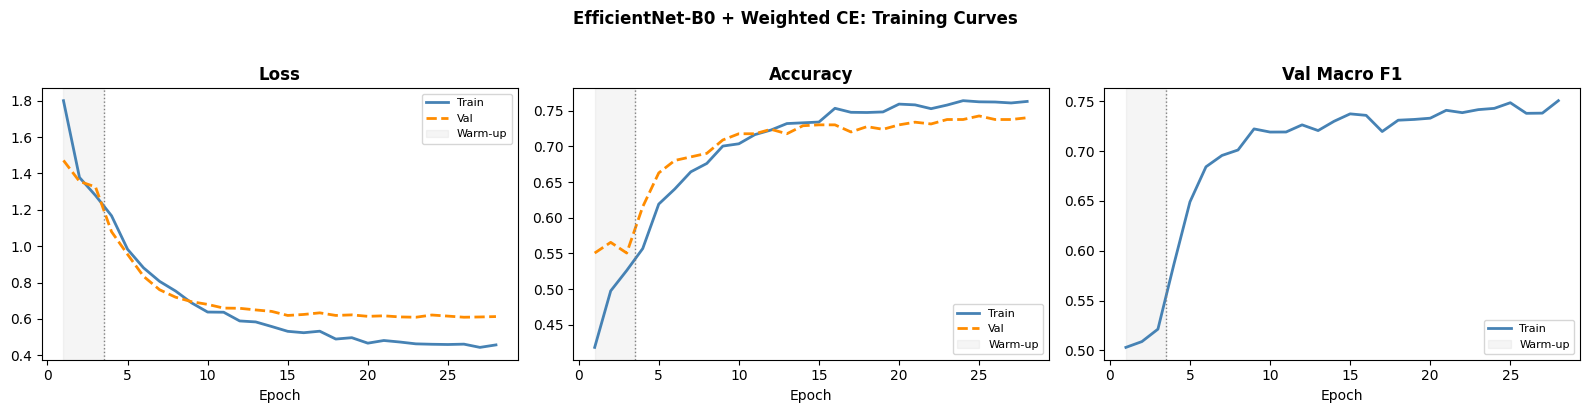

Saved → /content/retinal-disease-classification/figures/training_curves/efficientnet_wce.png


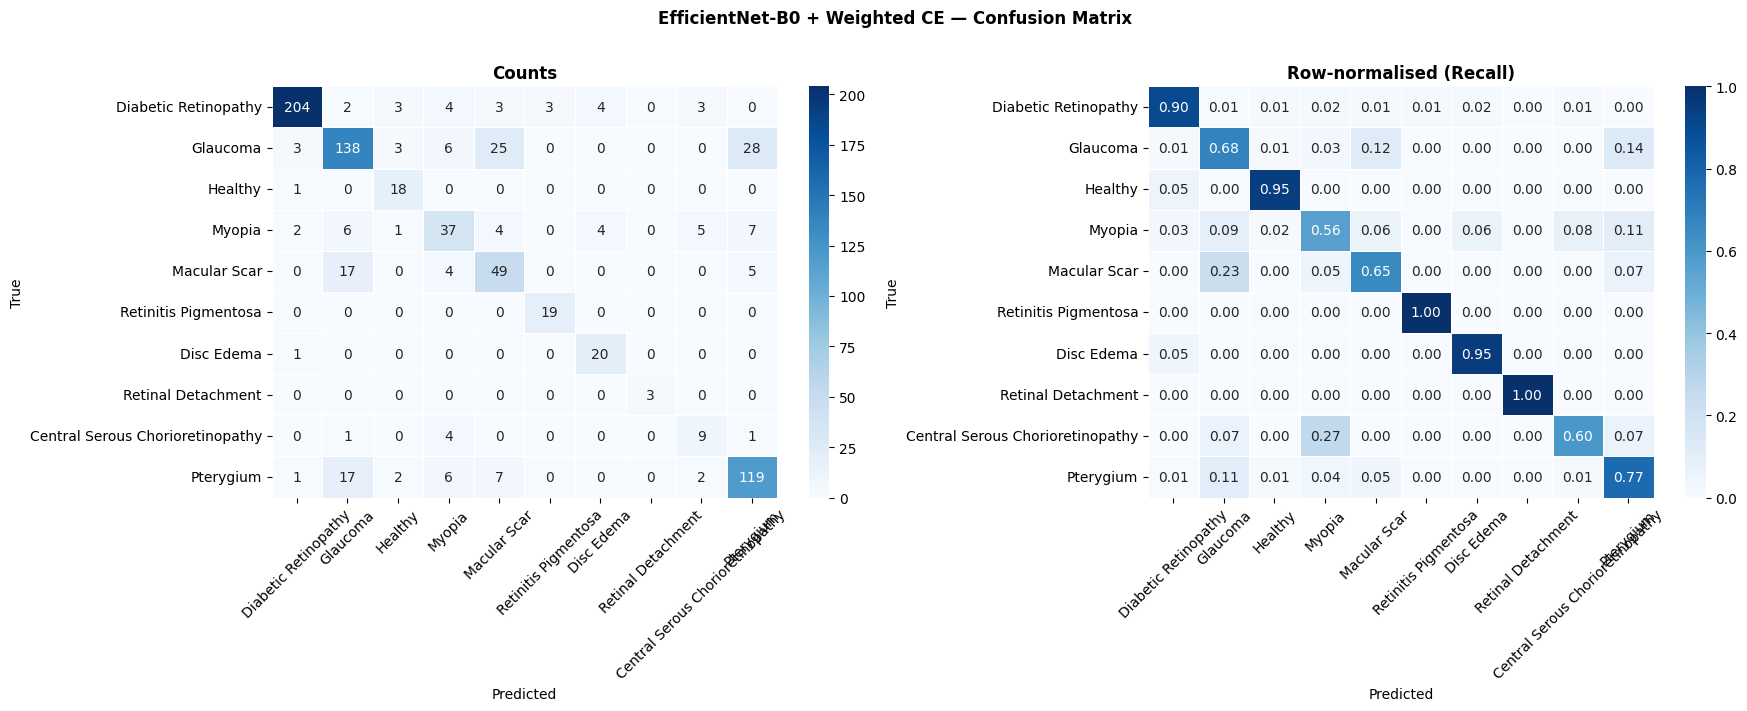

Saved → /content/retinal-disease-classification/figures/confusion_matrix_efficientnet_wce.png


In [16]:
RUN1_NAME = 'efficientnet_wce'

model_run1 = build_efficientnet(num_classes=NUM_CLASSES, freeze_backbone=True)
results_run1, history_run1, cm_run1 = train_model(
    run_name    = RUN1_NAME,
    model       = model_run1,
    criterion   = criterion_wce,
    models_dir  = MODELS_DIR,
    figures_dir = FIGURES,
)

plot_training_curves(
    history_run1, 'EfficientNet-B0 + Weighted CE',
    FIGURES / 'training_curves' / f'{RUN1_NAME}.png'
)
plot_confusion_matrix(
    np.array(cm_run1), 'EfficientNet-B0 + Weighted CE',
    FIGURES / f'confusion_matrix_{RUN1_NAME}.png'
)

---
## 6. Run 2: EfficientNet-B0 + Focal Loss


 RUN: efficientnet_focal

Phase 1: Warm-up (3 epochs, head only, lr=0.001)


  [W01] Loss 0.1126/0.0596 | Acc 0.069/0.090 | F1 0.186 | 228s ← best


  [W02] Loss 0.0529/0.0513 | Acc 0.105/0.112 | F1 0.208 | 229s ← best


  [W03] Loss 0.0452/0.0476 | Acc 0.125/0.142 | F1 0.227 | 236s ← best

Phase 2: Full fine-tuning (25 epochs, lr=3e-05)


  [F01] Loss 0.0382/0.0358 | Acc 0.145/0.177 | F1 0.286 | 232s ← best


...

  [F22] Loss 0.0086/0.0172 | Acc 0.422/0.451 | F1 0.515 | 230s


  [F23] Loss 0.0079/0.0180 | Acc 0.427/0.469 | F1 0.527 | 226s ← best


  [F24] Loss 0.0082/0.0171 | Acc 0.434/0.446 | F1 0.515 | 225s


  [F25] Loss 0.0084/0.0174 | Acc 0.426/0.452 | F1 0.513 | 223s [safety saved]

Loading best checkpoint (val F1=0.5272) for test evaluation...


Test Accuracy : 0.4757
Test Macro F1 : 0.5037

                                  precision    recall  f1-score   support

            Diabetic Retinopathy       1.00      0.32      0.48       226
                        Glaucoma       0.81      0.27      0.41       203
                         Healthy       0.42      1.00      0.59        19
                          Myopia       0.32      0.45      0.38        66
                    Macular Scar       0.39      0.71      0.50        75
            Retinitis Pigmentosa       0.43      1.00      0.60        19
                      Disc Edema       0.23      1.00      0.38        21
              Retinal Detachment       0.75      1.00      0.86         3
Central Serous Chorioretinopathy       0.11      0.73      0.20        15
                       Pterygium       0.65      0.64      0.64       154

                        accuracy                           0.48       801
                       macro avg       0.51      0.71      0.50

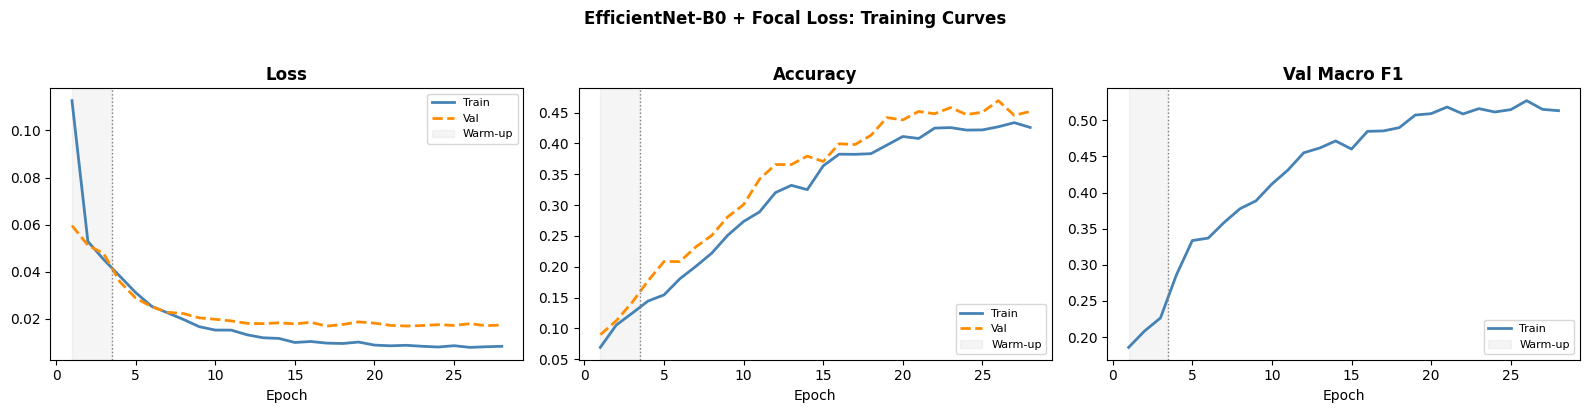

Saved → /content/retinal-disease-classification/figures/training_curves/efficientnet_focal.png


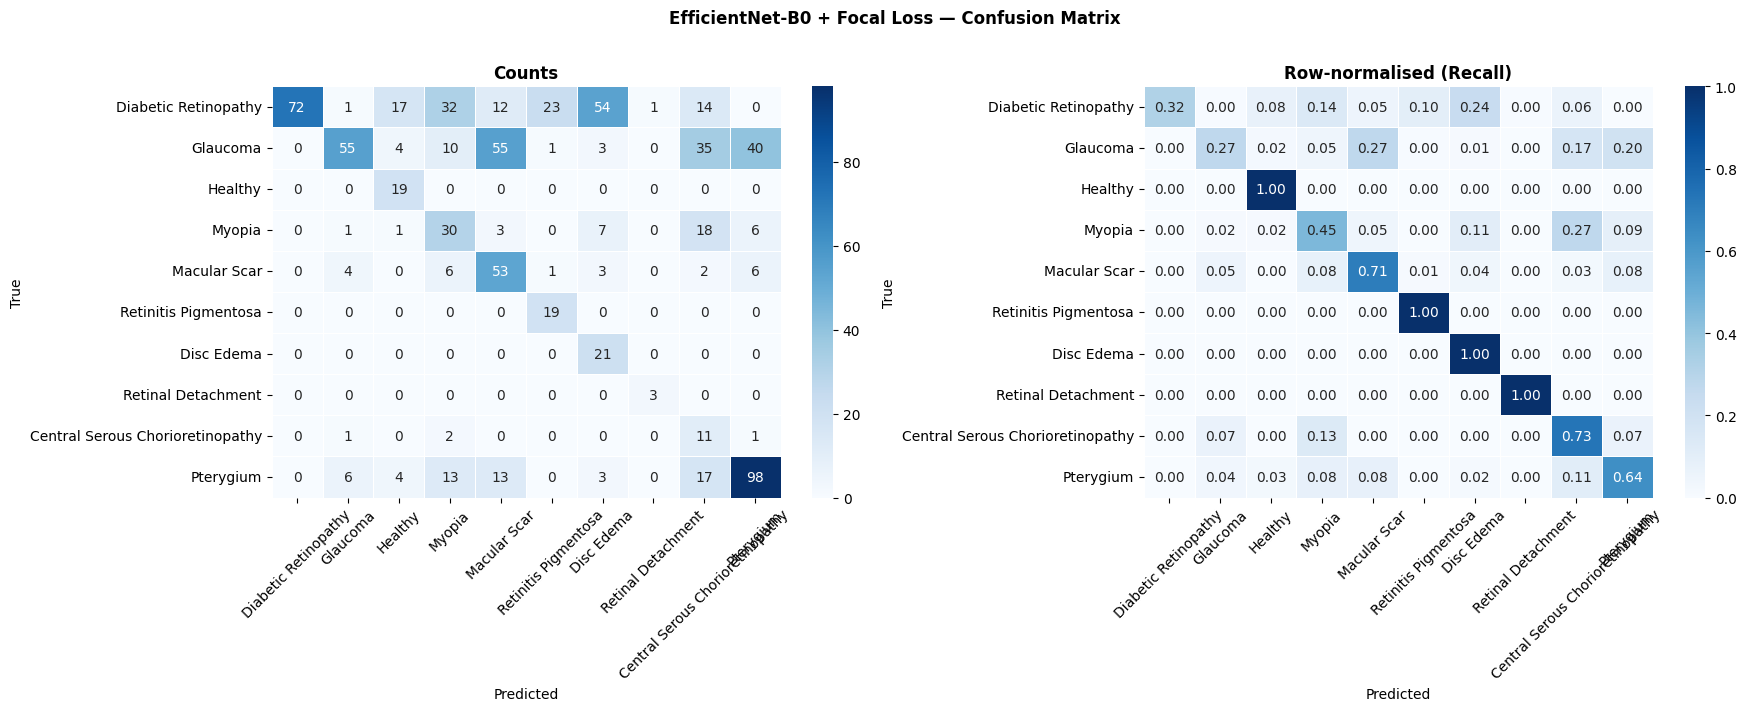

Saved → /content/retinal-disease-classification/figures/confusion_matrix_efficientnet_focal.png


In [18]:
RUN2_NAME = 'efficientnet_focal'

model_run2 = build_efficientnet(num_classes=NUM_CLASSES, freeze_backbone=True)
results_run2, history_run2, cm_run2 = train_model(
    run_name    = RUN2_NAME,
    model       = model_run2,
    criterion   = criterion_focal,
    models_dir  = MODELS_DIR,
    figures_dir = FIGURES,
)

plot_training_curves(
    history_run2, 'EfficientNet-B0 + Focal Loss',
    FIGURES / 'training_curves' / f'{RUN2_NAME}.png'
)
plot_confusion_matrix(
    np.array(cm_run2), 'EfficientNet-B0 + Focal Loss',
    FIGURES / f'confusion_matrix_{RUN2_NAME}.png'
)

---
## 7. Run 3: ConvNeXt-Tiny + Weighted Cross-Entropy

In [ ]:
RUN3_NAME = 'convnext_wce'

model_run3 = build_convnext(num_classes=NUM_CLASSES, freeze_backbone=True)
results_run3, history_run3, cm_run3 = train_model(
    run_name    = RUN3_NAME,
    model       = model_run3,
    criterion   = criterion_wce,
    models_dir  = MODELS_DIR,
    figures_dir = FIGURES,
)

plot_training_curves(
    history_run3, 'ConvNeXt-Tiny + Weighted CE',
    FIGURES / 'training_curves' / f'{RUN3_NAME}.png'
)
plot_confusion_matrix(
    np.array(cm_run3), 'ConvNeXt-Tiny + Weighted CE',
    FIGURES / f'confusion_matrix_{RUN3_NAME}.png'
)


 RUN: convnext_wce

Phase 1: Warm-up (3 epochs, head only, lr=0.001)


  [W01] Loss 1.5442/1.2050 | Acc 0.461/0.547 | F1 0.522 | 237s ← best


  [W02] Loss 1.0708/1.2626 | Acc 0.569/0.604 | F1 0.549 | 228s ← best


  [W03] Loss 0.9567/1.0819 | Acc 0.626/0.623 | F1 0.574 | 229s ← best

Phase 2: Full fine-tuning (25 epochs, lr=3e-05)


  [F01] Loss 1.1331/0.8464 | Acc 0.608/0.694 | F1 0.643 | 261s ← best


...

  [F04] Loss 0.4959/0.6874 | Acc 0.772/0.749 | F1 0.772 | 259s ← best


  [F05] Loss 0.4892/0.5818 | Acc 0.776/0.765 | F1 0.763 | 266s [safety saved]


  [F06] Loss 0.3780/0.5903 | Acc 0.820/0.768 | F1 0.775 | 259s ← best


  [F07] Loss 0.3357/0.6116 | Acc 0.834/0.740 | F1 0.761 | 266s


  Eval :   0%|          | 0/26 [00:00<?, ?it/s]

---
## 8. Run 4: ConvNeXt-Tiny + Focal Loss

In [ ]:
RUN4_NAME = 'convnext_focal'

model_run4 = build_convnext(num_classes=NUM_CLASSES, freeze_backbone=True)
results_run4, history_run4, cm_run4 = train_model(
    run_name    = RUN4_NAME,
    model       = model_run4,
    criterion   = criterion_focal,
    models_dir  = MODELS_DIR,
    figures_dir = FIGURES,
)

plot_training_curves(
    history_run4, 'ConvNeXt-Tiny + Focal Loss',
    FIGURES / 'training_curves' / f'{RUN4_NAME}.png'
)
plot_confusion_matrix(
    np.array(cm_run4), 'ConvNeXt-Tiny + Focal Loss',
    FIGURES / f'confusion_matrix_{RUN4_NAME}.png'
)

---
## 9. Cross-Run Comparison

In [ ]:
# Summary table
all_results = [results_run1, results_run2, results_run3, results_run4]

df_results = pd.DataFrame([{
    'Run':          r['run_name'],
    'Architecture': 'EfficientNet-B0' if 'efficientnet' in r['run_name'] else 'ConvNeXt-Tiny',
    'Loss':         'Focal' if 'focal' in r['run_name'] else 'Weighted CE',
    'Val F1':       r['best_val_f1'],
    'Test Acc':     r['test_acc'],
    'Test Macro F1': r['test_macro_f1'],
} for r in all_results])

print('=== RESULTS SUMMARY ===')
print(df_results.to_string(index=False))
print()
best_run = df_results.loc[df_results['Test Macro F1'].idxmax()]
print(f'Best model: {best_run["Run"]} (Test Macro F1 = {best_run["Test Macro F1"]})')

In [ ]:
# All training curves on one plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colours = {
    'efficientnet_wce':   ('steelblue',  '-'),
    'efficientnet_focal': ('steelblue',  '--'),
    'convnext_wce':       ('darkorange', '-'),
    'convnext_focal':     ('darkorange', '--'),
}
labels = {
    'efficientnet_wce':   'EfficientNet + WCE',
    'efficientnet_focal': 'EfficientNet + Focal',
    'convnext_wce':       'ConvNeXt + WCE',
    'convnext_focal':     'ConvNeXt + Focal',
}

for run_name, history in [
    ('efficientnet_wce',   history_run1),
    ('efficientnet_focal', history_run2),
    ('convnext_wce',       history_run3),
    ('convnext_focal',     history_run4),
]:
    colour, ls = colours[run_name]
    label      = labels[run_name]
    epochs     = range(1, len(history['val_loss']) + 1)
    axes[0].plot(epochs, history['val_loss'], color=colour, linestyle=ls,
                 linewidth=2, label=label)
    axes[1].plot(epochs, history['val_f1'],   color=colour, linestyle=ls,
                 linewidth=2, label=label)

axes[0].set_title('Validation Loss',     fontweight='bold')
axes[1].set_title('Validation Macro F1', fontweight='bold')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)

plt.suptitle('All Runs — Validation Curves Comparison', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'training_curves' / 'all_runs_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/training_curves/all_runs_comparison.png')

In [ ]:
# Save best model name for downstream notebooks
best_run_name = df_results.loc[df_results['Test Macro F1'].idxmax(), 'Run']
with open(MODELS_DIR / 'best_run.json', 'w') as f:
    json.dump({'best_run': best_run_name}, f)
print(f'Best run recorded: {best_run_name}')
print('Notebooks 04 and 05 will load this to select the correct model.')

---
## 10. Commit and Push

In [19]:
NB_SRC  = Path('/content/drive/MyDrive/Colab Notebooks/03_Architecture_Comparison.ipynb')
NB_DEST = REPO_DIR / 'notebooks' / '03_Architecture_Comparison.ipynb'
NB_DEST.parent.mkdir(parents=True, exist_ok=True)

if NB_SRC.exists():
    shutil.copy(NB_SRC, NB_DEST)
    print(f'Copied → {NB_DEST}')

assert NB_DEST.exists(), f'Copy failed — {NB_DEST} not found'

%cd {REPO_DIR}
!git add /content/retinal-disease-classification/notebooks/03_Architecture_Comparison.ipynb figures/
!git status
!git commit -m "Run 2: EfficientNet-B0 + Focal Loss; complete"
!git push
print('Done; Notebook 03 committed and pushed.')

Copied → /content/retinal-disease-classification/notebooks/03_Architecture_Comparison.ipynb
/content/retinal-disease-classification
On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   figures/confusion_matrix_efficientnet_focal.png
	new file:   figures/training_curves/efficientnet_focal.png
	modified:   notebooks/03_Architecture_Comparison.ipynb

[main 5839ca7] Run 2: EfficientNet-B0 + Focal Loss; complete
 3 files changed, 1 insertion(+), 1 deletion(-)
 create mode 100644 figures/confusion_matrix_efficientnet_focal.png
 create mode 100644 figures/training_curves/efficientnet_focal.png
Enumerating objects: 13, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (8/8), 489.02 KiB | 2.05 MiB/s, done.
Total 8 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), complete